In [117]:
import pandas as pd
import numpy as np

In [118]:
df = pd.read_csv('/content/modified_placement_data.csv')

In [119]:
df.sample(3)

,cgpa,iq,placement
36,"5,7",140.0,No
14,"6,1",103.0,No
8,"6,1",156.0,No


In [120]:
df.head()

,cgpa,iq,placement
0,"6,8",123.0,Yes
1,"5,9",106.0,No
2,"5,3",121.0,No
3,"7,4",132.0,Yes
4,"5,8",142.0,No


### See about Data

In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       95 non-null     object 
 1   iq         100 non-null    float64
 2   placement  100 non-null    object 
dtypes: float64(1), object(2)
memory usage: 2.5+ KB


In [122]:
df.shape

(100, 3)

## Univariant Analysis


### For IQ Column

####**conclusion**
- IQ is normally distributed
- No missing values
- There are may be 2 outliers above 200 iq

In [123]:
df['iq'].describe()

,iq
count,100.000000
mean,123.580000
std,39.944198
min,37.000000
25%,101.500000
50%,127.500000
75%,149.000000
max,233.000000


<Axes: ylabel='Frequency'>

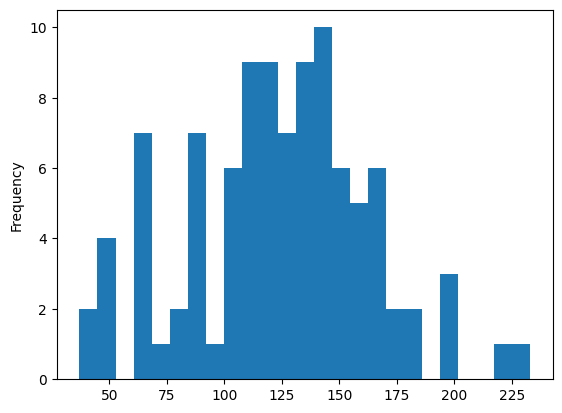

In [124]:
df['iq'].plot(kind='hist', bins=25)

<Axes: ylabel='Density'>

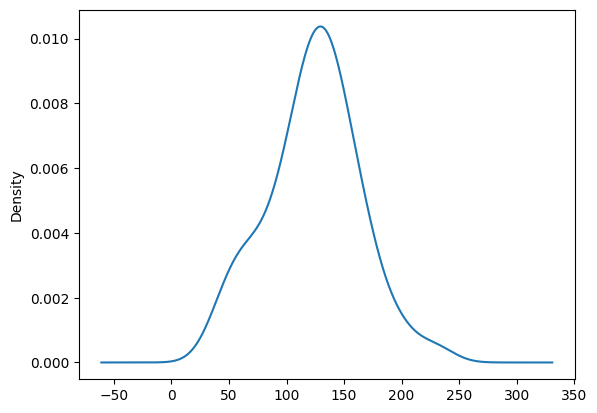

In [125]:
df['iq'].plot(kind='kde')

##### Its like normal but not acetly normalm distribution. Now we calculate skew near to zero means good like a normal distribution.

In [126]:
df['iq'].skew()

np.float64(0.018095580898964243)

<Axes: >

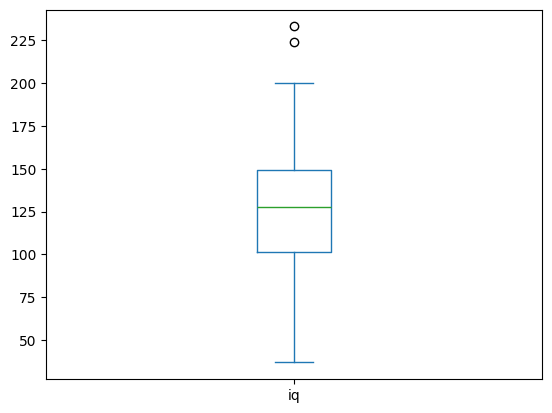

In [127]:
df['iq'].plot(kind='box')

#### Now we can see the outlier. Above 200 iq approx

In [128]:
df[df['iq'] > 201]

,cgpa,iq,placement
16,"5,2",224.0,No
50,"3,5",233.0,No


In [129]:
df['iq'].isnull().sum()
# Is there any null value, no

np.int64(0)

### Now for CGPA Column

####**Conclusion**
- First CGPA is like CSV type because comma like values.
- 5 null values here.

In [130]:
df['cgpa'].isnull().sum()

np.int64(5)

# Task
Clean, handle missing values, and perform univariate analysis on the 'cgpa' column in the `df` DataFrame. This includes converting the column to numeric, imputing the 5 missing values, generating descriptive statistics, distribution plots (histogram, KDE), skewness, and a box plot for outlier detection. Finally, summarize the cleaning steps and insights from the analysis.

## Clean CGPA Column

### Subtask:
Convert the 'cgpa' column from object type to numeric by replacing commas with dots and then casting to float.


**Reasoning**:
To clean the 'cgpa' column, I need to replace commas with dots and then convert the column to a float data type. After the conversion, I will display the DataFrame's info to verify the data type change and the head to show the cleaned values.



In [131]:
df['cgpa'] = df['cgpa'].str.replace(',', '.', regex=False).astype(float)

In [132]:
df['cgpa']

,cgpa
0,6.8
1,5.9
2,5.3
3,7.4
4,5.8
...,...
95,4.3
96,4.4
97,6.7
98,6.3


In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       95 non-null     float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    object 
dtypes: float64(2), object(1)
memory usage: 2.5+ KB


In [134]:
df['cgpa'].describe()

,cgpa
count,95.000000
mean,5.988421
std,1.157112
min,3.300000
25%,5.000000
50%,6.000000
75%,6.900000
max,8.500000


In [135]:
df['cgpa'].isnull().sum()

np.int64(5)

**Reasoning**:
The previous code failed because the `.str` accessor can only be used on string-like data, and `df['cgpa']` might have contained non-string types or its dtype was not properly recognized as string-like. To robustly convert the 'cgpa' column from object type (containing strings with commas) to numeric (float), I will explicitly convert it to string first, then replace commas with dots, and finally convert it to a numeric type, coercing any errors to NaN.



In [136]:
df['cgpa'] = df['cgpa'].astype(str).str.replace(',', '.', regex=False)
df['cgpa'] = pd.to_numeric(df['cgpa'], errors='coerce')

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       95 non-null     float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    object 
dtypes: float64(2), object(1)
memory usage: 2.5+ KB


,cgpa,iq,placement
0,6.8,123.0,Yes
1,5.9,106.0,No
2,5.3,121.0,No
3,7.4,132.0,Yes
4,5.8,142.0,No


## Handle Missing Values

### Subtask:
Impute the 5 missing values in the 'cgpa' column, for instance, by filling them with the mean of the column.


**Reasoning**:
To impute the missing values in the 'cgpa' column, I will first calculate its mean and then use the `fillna()` method to replace the NaN values with this calculated mean. Afterward, I will verify the imputation by checking for null values and displaying the DataFrame information.



In [137]:
cgpa_mean = df['cgpa'].mean()
df['cgpa'].fillna(cgpa_mean, inplace=True)
print(f"Missing values after imputation: {df['cgpa'].isnull().sum()}")
df.info()

Missing values after imputation: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    object 
dtypes: float64(2), object(1)
memory usage: 2.5+ KB


/tmp/ipykernel_229/1700220391.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['cgpa'].fillna(cgpa_mean, inplace=True)


**Reasoning**:
The previous code generated a `FutureWarning` regarding `inplace=True` with chained assignment. To address this, I will explicitly reassign the result of `fillna()` back to the column, which is the recommended practice for pandas 3.0 and avoids modifying a view or copy.



In [138]:
cgpa_mean = df['cgpa'].mean()
df['cgpa'] = df['cgpa'].fillna(cgpa_mean)
print(f"Missing values after imputation: {df['cgpa'].isnull().sum()}")
df.info()

Missing values after imputation: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    object 
dtypes: float64(2), object(1)
memory usage: 2.5+ KB


## Perform Univariate Analysis for CGPA

### Subtask:
Perform a univariate analysis on the cleaned 'cgpa' column, including descriptive statistics, distribution plots (histogram, KDE), skewness calculation, and a box plot to identify outliers.


**Reasoning**:
To begin the univariate analysis, I will generate descriptive statistics for the 'cgpa' column to understand its central tendency, dispersion, and shape.



In [139]:
df['cgpa'].describe()

,cgpa
count,100.000000
mean,5.988421
std,1.127513
min,3.300000
25%,5.075000
50%,6.000000
75%,6.825000
max,8.500000


**Reasoning**:
Following the univariate analysis instructions, I will generate a histogram for the 'cgpa' column to visualize its distribution. A histogram with 25 bins will provide a good initial view of the data's frequency distribution.



<Axes: ylabel='Frequency'>

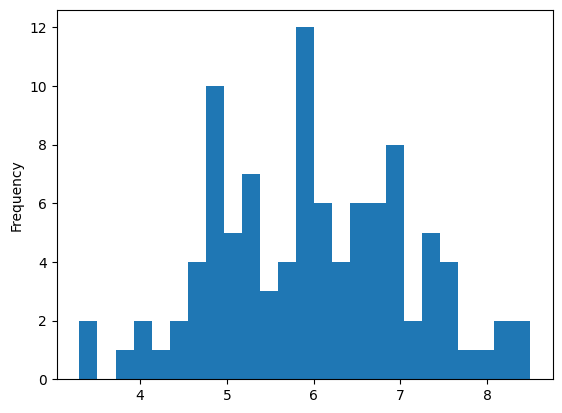

In [140]:
df['cgpa'].plot(kind='hist', bins=25)

**Reasoning**:
To further visualize the distribution of the 'cgpa' column, I will create a Kernel Density Estimate (KDE) plot. This will provide a smoothed representation of the data's probability density.



<Axes: ylabel='Density'>

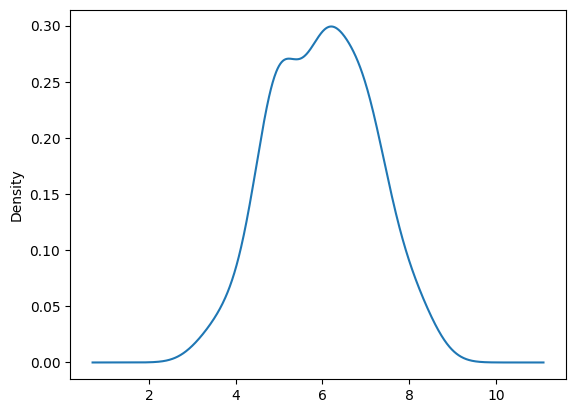

In [141]:
df['cgpa'].plot(kind='kde')

**Reasoning**:
To quantify the symmetry of the 'cgpa' column's distribution, I will calculate its skewness using the `.skew()` method. This will help determine if the distribution is skewed left, right, or is approximately symmetrical.



In [142]:
df['cgpa'].skew()

np.float64(-0.012303145115040146)

**Reasoning**:
To identify outliers in the 'cgpa' column, I will generate a box plot. This visualization will clearly show the spread of the data and any potential outliers.



**Skew Value**
If your skewness value is negative, it means the distribution is negatively skewed (or left-skewed). This implies that the tail of the distribution is longer on the left side, and the majority of the data points are concentrated on the right side of the mean. If your skewness value is positive, it means the distribution is positively skewed (or right-skewed). This implies that the tail of the distribution is longer on the right side, and the majority of the data points are concentrated on the left side of the mean.

<Axes: >

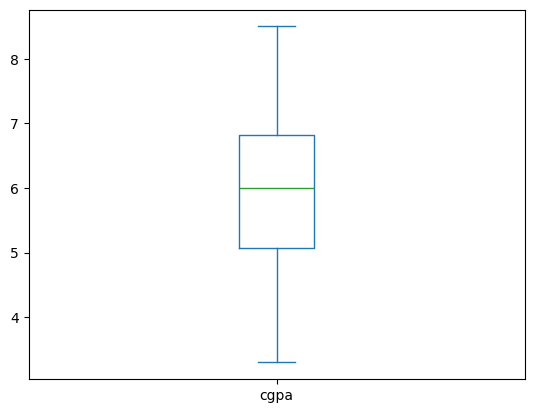

In [143]:
df['cgpa'].plot(kind='box')

## Summary of CGPA Column Analysis

### Cleaning Steps:
1.  **Type Conversion**: The 'cgpa' column was initially an `object` type with comma-separated decimal values. It was converted to `float64` by first converting to `string`, replacing commas with dots, and then using `pd.to_numeric` with `errors='coerce'` to handle potential non-numeric values gracefully.
2.  **Missing Value Imputation**: The 'cgpa' column had 5 missing values (NaNs). These missing values were successfully imputed by filling them with the mean of the column (`5.988`). After imputation, there are no missing values in the 'cgpa' column.

### Univariate Analysis Insights:
-   **Descriptive Statistics**:
    -   `count`: 100 (all values are now present after imputation)
    -   `mean`: 5.99
    -   `std`: 1.13
    -   `min`: 3.30
    -   `25% (Q1)`: 5.08
    -   `50% (Median)`: 6.00
    -   `75% (Q3)`: 6.83
    -   `max`: 8.50
-   **Distribution (Histogram and KDE Plot)**: The distribution of 'cgpa' appears to be relatively symmetrical and somewhat normally distributed, centered around the mean of 5.99.
-   **Skewness**: The calculated skewness is approximately -0.012, which is very close to zero. This indicates that the 'cgpa' distribution is nearly symmetrical.
-   **Outlier Detection (Box Plot)**: The box plot shows no significant outliers in the 'cgpa' column, indicating that most values fall within the expected range without extreme deviations.

## Final Task

### Subtask:
Summarize the cleaning steps and insights from the univariate analysis of the 'cgpa' column.


## Summary:

### Q&A
The cleaning steps involved converting the 'cgpa' column from an object type to a numeric (`float64`) by replacing commas with dots and then imputing 5 missing values with the mean. The univariate analysis showed that the 'cgpa' column has a nearly symmetrical distribution with no significant outliers.

### Data Analysis Key Findings
*   **Data Type Conversion**: The 'cgpa' column was successfully converted from an object type (string with commas) to `float64`. This involved explicitly casting to string, replacing commas (`,`) with dots (`.`), and then converting to numeric, coercing any errors to NaN.
*   **Missing Value Imputation**: The 5 missing values (NaNs) in the 'cgpa' column were successfully imputed using the mean of the column, which was approximately 5.988. After imputation, there are no missing values in the 'cgpa' column.
*   **Descriptive Statistics**:
    *   The `cgpa` column has 100 entries.
    *   The mean CGPA is approximately 5.99, and the median is 6.00, indicating a central tendency around this value.
    *   The standard deviation is 1.13, showing the spread of the data.
    *   CGPA values range from a minimum of 3.30 to a maximum of 8.50.
*   **Distribution**: Both histogram and Kernel Density Estimate (KDE) plots reveal that the 'cgpa' distribution is relatively symmetrical and somewhat normally distributed around its mean.
*   **Skewness**: The calculated skewness value is approximately -0.012, which is very close to zero, quantitatively confirming the visual observation of a nearly symmetrical distribution.
*   **Outlier Detection**: The box plot for 'cgpa' indicated no significant outliers, suggesting that all values fall within the expected range without extreme deviations.

### Insights or Next Steps
*   The 'cgpa' column is well-behaved, exhibiting a symmetrical distribution without outliers, making it suitable for direct use in further statistical analysis or modeling without requiring complex transformations.
*   Further analysis could explore the relationships between 'cgpa' and other numerical or categorical features in the dataset to identify potential correlations or group-wise differences.


In [144]:
df['placement'].value_counts()

,count
placement,
Yes,50
No,50


<Axes: ylabel='count'>

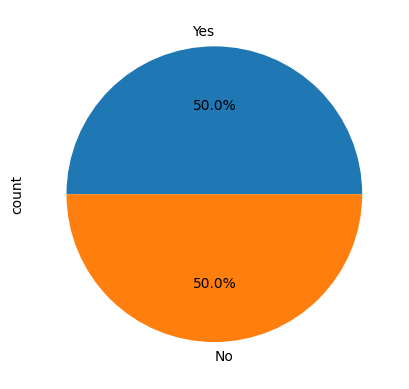

In [145]:
df['placement'].value_counts().plot(kind='pie', autopct='%0.1f%%')

In [146]:
df['placement'].isnull().sum()

np.int64(0)

In [147]:
# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [148]:
# One step we have to convert Yes -> 1 and No -> 0

In [149]:
df['placement'] = df['placement'].map({'Yes': 1, 'No': 0})
df['placement'].value_counts()

,count
placement,
1,50
0,50


In [150]:
import matplotlib.pyplot as plt

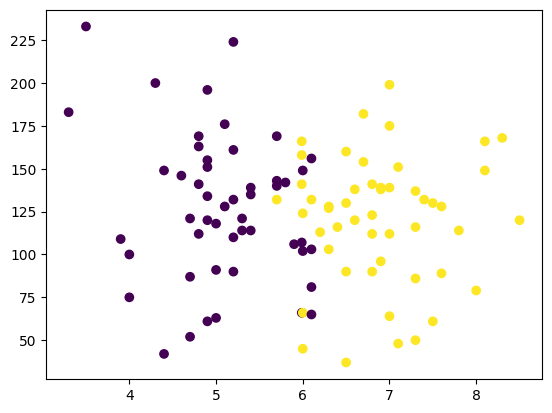

In [151]:
plt.scatter(df['cgpa'], df['iq'], c=df['placement'])

In [152]:
X = df.iloc[:, 0:2]
y = df.iloc[:, -1]

In [153]:
# Splite train and test data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [154]:
X_train.sample(4)

,cgpa,iq
65,8.100000,166.0
85,5.988421,166.0
11,6.900000,138.0
76,4.900000,155.0


In [155]:
# Now I have to scaler this columns.
from sklearn.preprocessing import StandardScaler

In [156]:
scaler = StandardScaler()


In [157]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [158]:
from sklearn.linear_model import LogisticRegression

In [159]:
clf = LogisticRegression()

In [160]:
# Model training
clf.fit(X_train, y_train)

LogisticRegression()

In [161]:
y_pred = clf.predict(X_test)

In [162]:
y_pred

array([1, 1, 1, 0, 1, 0, 0, 0, 0, 1])

In [163]:
from sklearn.metrics import accuracy_score

In [164]:
accuracy_score(y_test, y_pred)

0.8

In [165]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

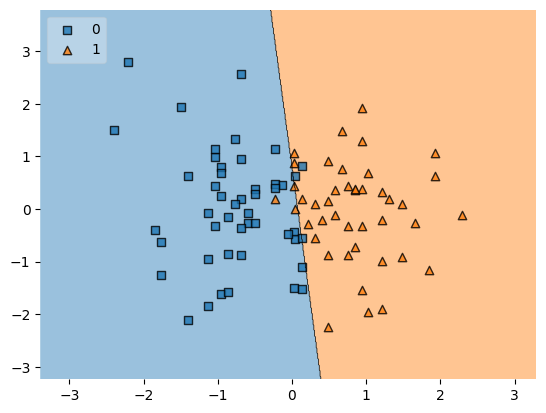

In [166]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)